# Importing the Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Reading the Data

In [2]:
df = pd.read_excel("Africa.xlsx")

In [3]:
df

,ID,Country,Region,Population 2024 ( millions ),Population 2025 ( millions ),Nominal GDP 2024 ( billions USD ),Nominal GDP 2025 ( billions USD ),GDP PPP 2024 ( billions USD ),GDP PPP 2025 ( billions USD )
0,1,Algeria,Nothern Africa,46.814,47.435,269.140,288.013,826.100,874.599
1,2,Angola,Southern Africa,37.885,39.040,115.214,115.167,383.923,401.480
2,3,Benin,Western Africa,14.462,14.814,21.487,24.402,64.229,70.423
3,4,Botswana,Southern Africa,2.521,2.562,19.356,19.186,51.855,52.650
4,5,Burkina Faso,Western Africa,23.548,24.074,23.130,26.866,68.292,72.743
5,6,Burundi,Central Africa,14.047,14.390,4.827,7.025,13.386,14.314
6,7,Cabo Verde,Western Africa,0.524,0.527,2.726,2.915,5.885,6.340
7,8,Cameroon,Central Africa,29.123,29.879,54.394,60.577,162.748,173.034
8,9,Central African Republic,Central Africa,5.330,5.513,2.831,3.300,7.156,7.549
9,10,Chad,Central Africa,20.299,21.003,19.836,21.592,56.514,59.822


# Getting information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 9 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ID                                 54 non-null     int64  
 1   Country                            54 non-null     str    
 2   Region                             54 non-null     str    
 3   Population 2024 ( millions )       54 non-null     float64
 4   Population 2025 ( millions )       54 non-null     float64
 5   Nominal GDP 2024 ( billions USD )  54 non-null     float64
 6   Nominal GDP 2025 ( billions USD )  54 non-null     float64
 7   GDP PPP 2024 ( billions USD )      53 non-null     float64
 8   GDP PPP 2025 ( billions USD )      53 non-null     float64
dtypes: float64(6), int64(1), str(2)
memory usage: 3.9 KB


# Population per Region Analysis

In [5]:
region = df[["Region", "Population 2024 ( millions )", "Population 2025 ( millions )"]]

In [6]:
region

,Region,Population 2024 ( millions ),Population 2025 ( millions )
0,Nothern Africa,46.814,47.435
1,Southern Africa,37.885,39.040
2,Western Africa,14.462,14.814
3,Southern Africa,2.521,2.562
4,Western Africa,23.548,24.074
5,Central Africa,14.047,14.390
6,Western Africa,0.524,0.527
7,Central Africa,29.123,29.879
8,Central Africa,5.330,5.513
9,Central Africa,20.299,21.003


In [7]:
region_group = region.groupby("Region")

In [8]:
region_group_sum = region_group.sum()

In [9]:
region_group_sum

,Population 2024 ( millions ),Population 2025 ( millions )
Region,,
Central Africa,189.072,194.872
Eastern Africa,441.656,452.819
Nothern Africa,226.260,229.351
Southern Africa,205.256,209.770
Western Africa,451.068,461.204


(0.0, 500.0)

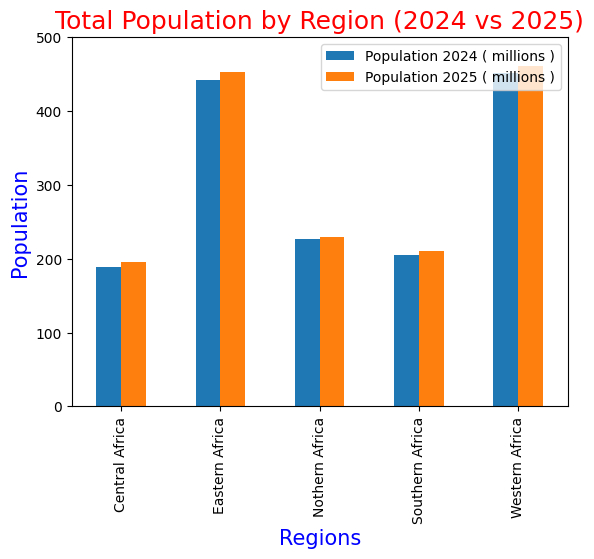

In [10]:
region_group_sum.plot(kind="bar")
plt.title("Total Population by Region (2024 vs 2025)", fontsize=18, color="red")
plt.xlabel("Regions", fontsize=15,color="blue")
plt.ylabel("Population", fontsize=15, color="blue")
plt.ylim(0, 500)

# Population's Growth Rate

In [11]:
df["Population growth rate"] = (((df["Population 2025 ( millions )"] - df["Population 2024 ( millions )"]) / df["Population 2024 ( millions )"]) * 100).round(2)

In [12]:
df

,ID,Country,Region,Population 2024 ( millions ),Population 2025 ( millions ),Nominal GDP 2024 ( billions USD ),Nominal GDP 2025 ( billions USD ),GDP PPP 2024 ( billions USD ),GDP PPP 2025 ( billions USD ),Population growth rate
0,1,Algeria,Nothern Africa,46.814,47.435,269.140,288.013,826.100,874.599,1.33
1,2,Angola,Southern Africa,37.885,39.040,115.214,115.167,383.923,401.480,3.05
2,3,Benin,Western Africa,14.462,14.814,21.487,24.402,64.229,70.423,2.43
3,4,Botswana,Southern Africa,2.521,2.562,19.356,19.186,51.855,52.650,1.63
4,5,Burkina Faso,Western Africa,23.548,24.074,23.130,26.866,68.292,72.743,2.23
5,6,Burundi,Central Africa,14.047,14.390,4.827,7.025,13.386,14.314,2.44
6,7,Cabo Verde,Western Africa,0.524,0.527,2.726,2.915,5.885,6.340,0.57
7,8,Cameroon,Central Africa,29.123,29.879,54.394,60.577,162.748,173.034,2.60
8,9,Central African Republic,Central Africa,5.330,5.513,2.831,3.300,7.156,7.549,3.43
9,10,Chad,Central Africa,20.299,21.003,19.836,21.592,56.514,59.822,3.47


# GDP per Region Analysis

In [13]:
df["Nominal GDP 2024 ( billions USD )"].sum()

np.float64(2892.7239999999997)

In [14]:
GDP = df[["Region", "Nominal GDP 2024 ( billions USD )"]]

In [15]:
GDP

,Region,Nominal GDP 2024 ( billions USD )
0,Nothern Africa,269.140
1,Southern Africa,115.214
2,Western Africa,21.487
3,Southern Africa,19.356
4,Western Africa,23.130
5,Central Africa,4.827
6,Western Africa,2.726
7,Central Africa,54.394
8,Central Africa,2.831
9,Central Africa,19.836


In [16]:
GDP_group = df.groupby("Region")

In [17]:
GDP_group_sum = GDP_group["Nominal GDP 2024 ( billions USD )"].sum()

In [18]:
GDP_group_sum

Region
Central Africa     205.657
Eastern Africa     499.685
Nothern Africa     925.142
Southern Africa    666.280
Western Africa     595.960
Name: Nominal GDP 2024 ( billions USD ), dtype: float64

In [19]:
GDP_group_sum_per = GDP_group_sum / df["Nominal GDP 2024 ( billions USD )"].sum() * 100

In [20]:
GDP_group_sum_per

Region
Central Africa      7.109458
Eastern Africa     17.273857
Nothern Africa     31.981689
Southern Africa    23.032961
Western Africa     20.602035
Name: Nominal GDP 2024 ( billions USD ), dtype: float64

Text(0.5, 1.0, 'Share of African Nominal GDP per Region in 2024')

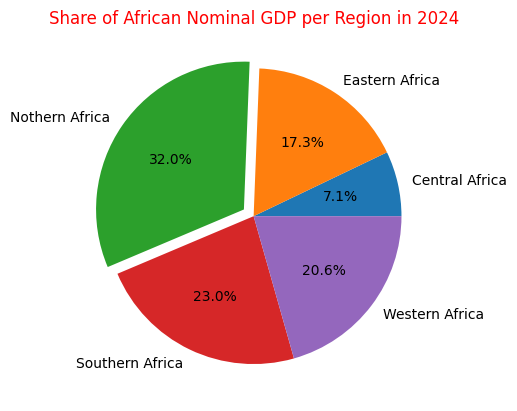

In [21]:
GDP_group_sum_per.plot(kind="pie", explode=[0, 0, 0.08, 0, 0], autopct="%1.1f%%")
plt.title("Share of African Nominal GDP per Region in 2024", fontsize=12, color="red")

In [22]:
GDP2 = df[["Region", "Nominal GDP 2025 ( billions USD )"]]

In [23]:
GDP2

,Region,Nominal GDP 2025 ( billions USD )
0,Nothern Africa,288.013
1,Southern Africa,115.167
2,Western Africa,24.402
3,Southern Africa,19.186
4,Western Africa,26.866
5,Central Africa,7.025
6,Western Africa,2.915
7,Central Africa,60.577
8,Central Africa,3.300
9,Central Africa,21.592


In [24]:
GDP_group2 = df.groupby("Region")

In [25]:
GDP_group_sum2 = GDP_group["Nominal GDP 2025 ( billions USD )"].sum()

In [26]:
GDP_group_sum2

Region
Central Africa     226.349
Eastern Africa     512.372
Nothern Africa     935.852
Southern Africa    705.393
Western Africa     693.463
Name: Nominal GDP 2025 ( billions USD ), dtype: float64

In [27]:
GDP_group_sum_per2 = GDP_group_sum / df["Nominal GDP 2025 ( billions USD )"].sum() * 100

In [28]:
GDP_group_sum_per2

Region
Central Africa      6.691451
Eastern Africa     16.258225
Nothern Africa     30.101297
Southern Africa    21.678718
Western Africa     19.390720
Name: Nominal GDP 2024 ( billions USD ), dtype: float64

Text(0.5, 1.0, 'Share of African Nominal GDP per Region in 2025')

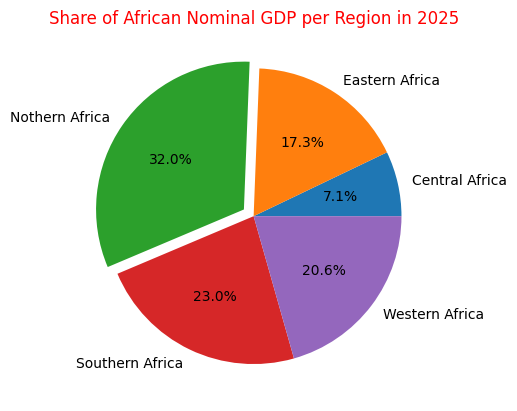

In [29]:
GDP_group_sum_per2.plot(kind="pie", explode=[0, 0, 0.08, 0, 0], autopct="%1.1f%%")
plt.title("Share of African Nominal GDP per Region in 2025", fontsize=12, color="red")

In [30]:
PPP = df[["Region", "GDP PPP 2024 ( billions USD )"]]

In [31]:
PPP_group = df.groupby("Region")

In [32]:
PPP_group_sum = PPP_group["GDP PPP 2024 ( billions USD )"].sum()

In [33]:
PPP_group_sum

Region
Central Africa      564.516
Eastern Africa     1587.934
Nothern Africa     3780.578
Southern Africa    1798.743
Western Africa     3151.211
Name: GDP PPP 2024 ( billions USD ), dtype: float64

In [34]:
PPP_group_sum_per = PPP_group_sum / df["GDP PPP 2024 ( billions USD )"].sum() * 100

Text(0.5, 1.0, 'Share of African GDP PPP per Region in 2024')

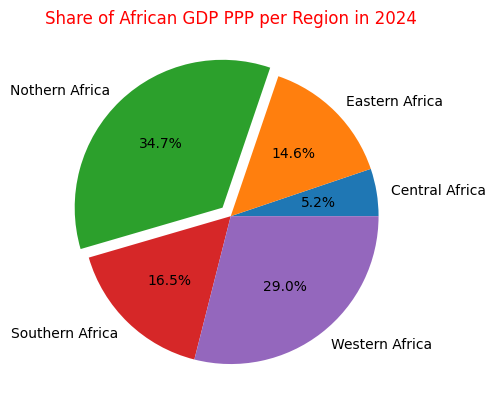

In [35]:
PPP_group_sum_per.plot(kind="pie", explode=[0, 0, 0.08, 0, 0], autopct="%1.1f%%")
plt.title("Share of African GDP PPP per Region in 2024", fontsize=12, color="red")

In [36]:
PPP2 = df[["Region", "GDP PPP 2025 ( billions USD )"]]

In [37]:
PPP_group2 = df.groupby("Region")

In [38]:
PPP_group_sum2 = PPP_group2["GDP PPP 2025 ( billions USD )"].sum()

In [39]:
PPP_group_sum_per2 = PPP_group_sum2 / df["GDP PPP 2025 ( billions USD )"].sum() * 100

Text(0.5, 1.0, 'Share of African GDP PPP per Region in 2025')

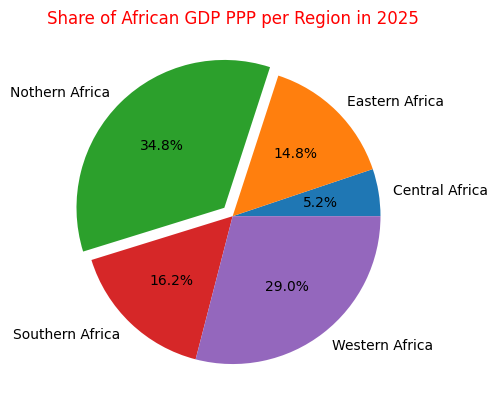

In [40]:
PPP_group_sum_per2.plot(kind="pie", explode=[0, 0, 0.08, 0, 0], autopct="%1.1f%%")
plt.title("Share of African GDP PPP per Region in 2025", fontsize=12, color="red")

# GDP per Capita

In [41]:
df["Nominal GDP Per Capita 2024"] = (df["Nominal GDP 2024 ( billions USD )"] / df["Population 2024 ( millions )"] * 1000)

In [42]:
df["GDP PPP Per Capita 2024"] = (df["GDP PPP 2024 ( billions USD )"] / df["Population 2024 ( millions )"] * 1000)

In [43]:
df["Nominal GDP Per Capita 2025"] = (df["Nominal GDP 2025 ( billions USD )"] / df["Population 2025 ( millions )"] * 1000)

In [44]:
df["GDP PPP Per Capita 2025"] = (df["GDP PPP 2025 ( billions USD )"] / df["Population 2025 ( millions )"] * 1000)

In [45]:
df

,ID,Country,Region,Population 2024 ( millions ),Population 2025 ( millions ),Nominal GDP 2024 ( billions USD ),Nominal GDP 2025 ( billions USD ),GDP PPP 2024 ( billions USD ),GDP PPP 2025 ( billions USD ),Population growth rate,Nominal GDP Per Capita 2024,GDP PPP Per Capita 2024,Nominal GDP Per Capita 2025,GDP PPP Per Capita 2025
0,1,Algeria,Nothern Africa,46.814,47.435,269.140,288.013,826.100,874.599,1.33,5749.134874,17646.430555,6071.740276,18437.841256
1,2,Angola,Southern Africa,37.885,39.040,115.214,115.167,383.923,401.480,3.05,3041.150851,10133.905240,2949.974385,10283.811475
2,3,Benin,Western Africa,14.462,14.814,21.487,24.402,64.229,70.423,2.43,1485.755774,4441.225280,1647.225597,4753.813960
3,4,Botswana,Southern Africa,2.521,2.562,19.356,19.186,51.855,52.650,1.63,7677.905593,20569.218564,7488.680718,20550.351288
4,5,Burkina Faso,Western Africa,23.548,24.074,23.130,26.866,68.292,72.743,2.23,982.249023,2900.118906,1115.975741,3021.641605
5,6,Burundi,Central Africa,14.047,14.390,4.827,7.025,13.386,14.314,2.44,343.632092,952.943689,488.186240,994.718555
6,7,Cabo Verde,Western Africa,0.524,0.527,2.726,2.915,5.885,6.340,0.57,5202.290076,11230.916031,5531.309298,12030.360531
7,8,Cameroon,Central Africa,29.123,29.879,54.394,60.577,162.748,173.034,2.60,1867.733407,5588.297909,2027.410556,5791.157669
8,9,Central African Republic,Central Africa,5.330,5.513,2.831,3.300,7.156,7.549,3.43,531.144465,1342.589118,598.585162,1369.308906
9,10,Chad,Central Africa,20.299,21.003,19.836,21.592,56.514,59.822,3.47,977.190995,2784.078033,1028.043613,2848.259772


# GDP per Capita's Growth Rate

In [46]:
df["Nominal GDP Per Capita Growth Rate"] = ((df["Nominal GDP Per Capita 2025"] - df["Nominal GDP Per Capita 2024"] / df["Nominal GDP Per Capita 2024"]) * 100)

In [59]:
df["GDP PPP Per Capita Growth Rate"] = round((df["GDP PPP Per Capita 2025"] - df["GDP PPP Per Capita 2024"] / df["GDP PPP Per Capita 2024"]) * 100)

In [60]:
df = df.drop(columns=["Nominal GDP Per Capita 2024 ( USD )", "GDP PPP Per Capita 2024 ( USD )", "Nominal GDP Per Capita 2025 ( USD )", "GDP PPP Per Capita 2025 ( USD )"])

KeyError: "['Nominal GDP Per Capita 2024 ( USD )', 'GDP PPP Per Capita 2024 ( USD )', 'Nominal GDP Per Capita 2025 ( USD )', 'GDP PPP Per Capita 2025 ( USD )'] not found in axis"

In [61]:
df

,ID,Country,Region,Population 2024 ( millions ),Population 2025 ( millions ),Nominal GDP 2024 ( billions USD ),Nominal GDP 2025 ( billions USD ),GDP PPP 2024 ( billions USD ),GDP PPP 2025 ( billions USD ),Population growth rate,Nominal GDP Per Capita 2024,GDP PPP Per Capita 2024,Nominal GDP Per Capita 2025,GDP PPP Per Capita 2025,Nominal GDP Per Capita Growth Rate,GDP PPP Per Capita Growth Rate
0,1,Algeria,Nothern Africa,46.814,47.435,269.140,288.013,826.100,874.599,1.33,5749.134874,17646.430555,6071.740276,18437.841256,6.070740e+05,1843684.0
1,2,Angola,Southern Africa,37.885,39.040,115.214,115.167,383.923,401.480,3.05,3041.150851,10133.905240,2949.974385,10283.811475,2.948974e+05,1028281.0
2,3,Benin,Western Africa,14.462,14.814,21.487,24.402,64.229,70.423,2.43,1485.755774,4441.225280,1647.225597,4753.813960,1.646226e+05,475281.0
3,4,Botswana,Southern Africa,2.521,2.562,19.356,19.186,51.855,52.650,1.63,7677.905593,20569.218564,7488.680718,20550.351288,7.487681e+05,2054935.0
4,5,Burkina Faso,Western Africa,23.548,24.074,23.130,26.866,68.292,72.743,2.23,982.249023,2900.118906,1115.975741,3021.641605,1.114976e+05,302064.0
5,6,Burundi,Central Africa,14.047,14.390,4.827,7.025,13.386,14.314,2.44,343.632092,952.943689,488.186240,994.718555,4.871862e+04,99372.0
6,7,Cabo Verde,Western Africa,0.524,0.527,2.726,2.915,5.885,6.340,0.57,5202.290076,11230.916031,5531.309298,12030.360531,5.530309e+05,1202936.0
7,8,Cameroon,Central Africa,29.123,29.879,54.394,60.577,162.748,173.034,2.60,1867.733407,5588.297909,2027.410556,5791.157669,2.026411e+05,579016.0
8,9,Central African Republic,Central Africa,5.330,5.513,2.831,3.300,7.156,7.549,3.43,531.144465,1342.589118,598.585162,1369.308906,5.975852e+04,136831.0
9,10,Chad,Central Africa,20.299,21.003,19.836,21.592,56.514,59.822,3.47,977.190995,2784.078033,1028.043613,2848.259772,1.027044e+05,284726.0
